In [3]:
import matplotlib.pyplot as plt
import numpy as np

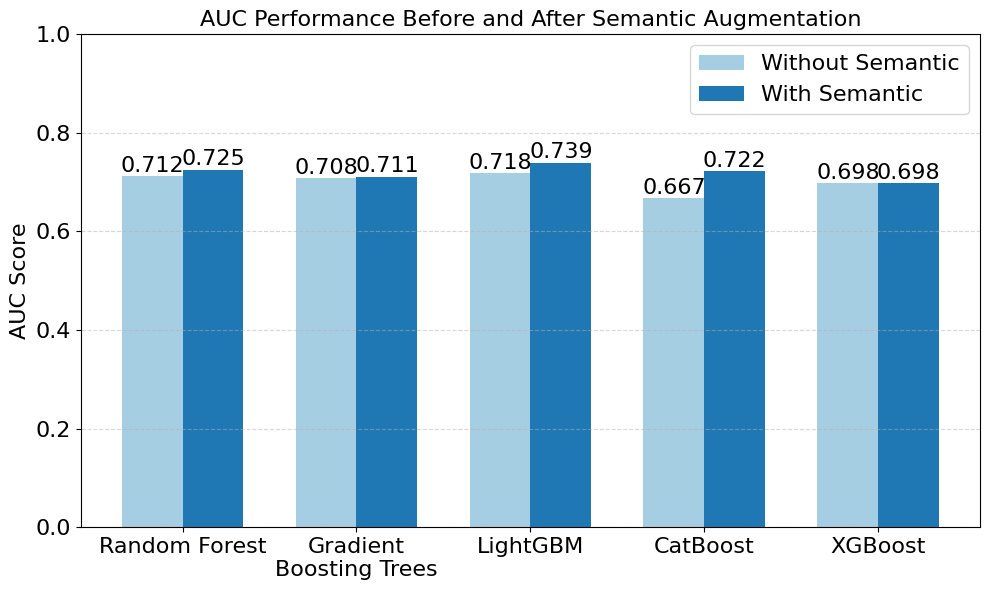

In [4]:
# 模型名称和对应的 AUC 值
models = ['Random Forest', 'Gradient\nBoosting Trees', 'LightGBM', 'CatBoost', 'XGBoost']
# auc_no_semantic = [0.6111, 0.6095, 0.6348, 0.6001, 0.6462]
# auc_with_semantic = [0.7124, 0.7083, 0.7177, 0.6671, 0.6977]
auc_no_semantic = [0.7124, 0.7083, 0.7177, 0.6671, 0.6977]
auc_with_semantic = [0.7254, 0.7108, 0.7390, 0.7222, 0.6977]

# 设置柱状图参数
x = np.arange(len(models))
width = 0.35

# 绘图
plt.figure(figsize=(10, 6))
# bars1 = plt.bar(x - width/2, auc_no_semantic, width, label='Without Semi-supervised Augmentation', color='#A6CEE3')
# bars2 = plt.bar(x + width/2, auc_with_semantic, width, label='With Semi-supervised Augmentation', color='#1F78B4')
bars1 = plt.bar(x - width/2, auc_no_semantic, width, label='Without Semantic', color='#A6CEE3')
bars2 = plt.bar(x + width/2, auc_with_semantic, width, label='With Semantic', color='#1F78B4')
# 添加数值标签
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.001, f'{height:.3f}', ha='center', va='bottom', fontsize=16)

# 图表设置
plt.ylabel('AUC Score', fontsize=16)
plt.title('AUC Performance Before and After Semantic Augmentation', fontsize=16)
plt.xticks(x, models, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0.00, 1.00)
plt.legend(fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 保存为 PDF 和 PNG
plt.savefig("Semantic Enhancement_AUC Comparison Chart_2.svg", format='svg')
plt.show()

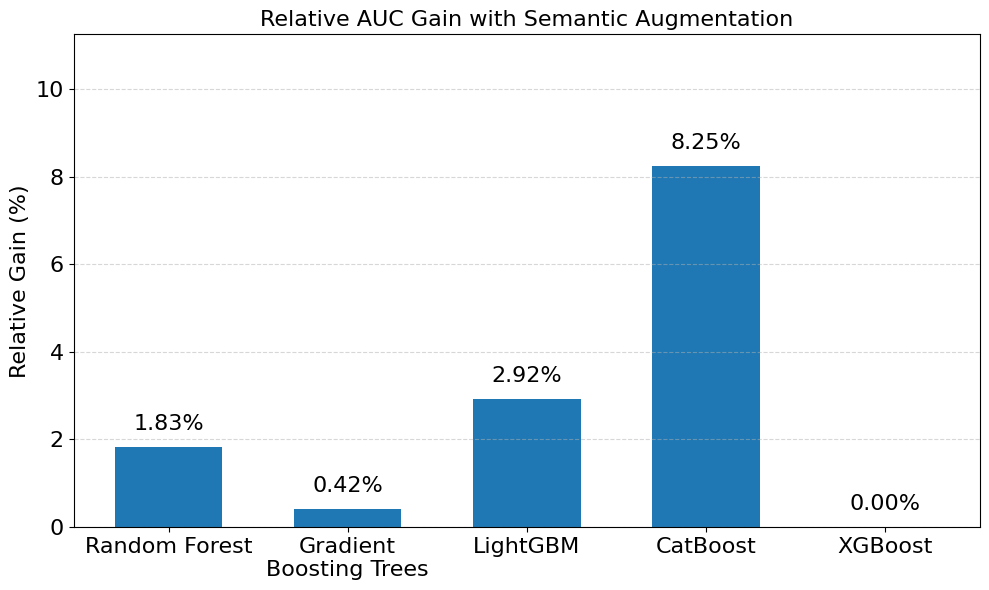

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 数据
models = ['Random Forest', 'Gradient\nBoosting Trees', 'LightGBM', 'CatBoost', 'XGBoost']
#relative_gain = [16.58, 16.21, 13.06, 11.16, 7.97]
relative_gain = [1.83, 0.42, 2.92, 8.25, 0.00]

# 设置柱状图参数
x = np.arange(len(models))
width = 0.6

# 创建图像
plt.figure(figsize=(10, 6))

# 绘制柱状图，颜色与第一张图协调（使用深蓝色）
bars = plt.bar(x, relative_gain, width, color='#1F78B4', label='Relative Gain (%)')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.2f}%', ha='center', va='bottom', fontsize=16)

# 图表设置
plt.ylabel('Relative Gain (%)', fontsize=16)
plt.title('Relative AUC Gain with Semantic Augmentation', fontsize=16)
plt.xticks(x, models, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, max(relative_gain) + 3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 保存为 PNG
plt.savefig("Semantic Enhancement_AUC Improvement Chart_2.svg", format='svg')

# 显示图形
plt.show()

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc

# 设置模型及其展示名称和颜色
models = {
    'rf': 'Random Forest',
    'gbt': 'Gradient Boosting Trees',
    'lgbm': 'LightGBM',
    'catb': 'CatBoost',
    'xgb': 'XGBoost'
}

colors = {
    'rf': 'tab:blue',
    'gbt': 'tab:orange',
    'lgbm': 'tab:green',
    'catb': 'tab:red',
    'xgb': 'tab:purple'
}

for model_key, model_name in models.items():
    plt.figure(figsize=(6, 5))
    
    # 读取无语义增强文件
    df_plain = pd.read_csv(f'{model_key}_bjd_roc_curve.csv')
    auc_plain = auc(df_plain['FPR'], df_plain['TPR'])
    plt.plot(df_plain['FPR'], df_plain['TPR'], linestyle='-', color=colors[model_key],
             label=f'Before Semantic (AUC={auc_plain:.3f})')

    # 读取有语义增强文件
    df_semantic = pd.read_csv(f'{model_key}_yy_roc_curve_2.csv')
    auc_semantic = auc(df_semantic['FPR'], df_semantic['TPR'])
    plt.plot(df_semantic['FPR'], df_semantic['TPR'], linestyle='--', color=colors[model_key],
             label=f'After Semantic (AUC={auc_semantic:.3f})')

    # 参考线
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

    # 图形设置
    plt.xlabel('False Positive Rate (FPR)', fontsize=16)
    plt.ylabel('True Positive Rate (TPR)', fontsize=16)
    plt.title(f'ROC Curve: {model_name}', fontsize=16)
    plt.legend(loc='lower right', fontsize=13)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)    
    plt.grid(True)
    plt.tight_layout()

    # 保存为单独图片
    filename = f"ROC_{model_key}_Semantic Augmentation_2.svg"
    #plt.savefig(filename, dpi=300)
    plt.savefig(filename, format='svg')
    plt.close()  # 关闭当前图形，防止图像重叠